# NN_02c — Ablation Study: z_eq Sufficiency & Feature Importance

## Objetivo

Este notebook investiga sistematicamente se o sinal normalizado `z_eq` é suficiente para autenticação em camada física, ou se parâmetros adicionais (ganho de canal $h$, SNR estimado, e correlator clássico $\tau_{eq}$) melhoram significativamente o desempenho de detecção.

## Variantes Investigadas

A investigação compara cinco variantes de entrada treinadas sob a mesma arquitetura DNN totalmente conectada. A **Variante A** estabelece a linha de base: uma rede densa que processa apenas o resíduo normalizado $z_{eq}$, contendo 1024 amostras do sinal equalizado. Esta variante testa se a representação vetorial bruta de $z_{eq}$ é suficientemente discriminatória para o classificador aprender sozinho sem ajuda externa.

A **Variante B** estende a Variante A incorporando o ganho de canal estimado $h$ como entrada auxiliar escalar. A motivação é validar se informação causal sobre o estado do canal instantâneo melhora a capacidade da rede de aprender limiares adaptativos conforme previsto pelo princípio CFAR.

A **Variante C** adiciona também a estimativa de SNR nominal ao vetor de entrada junto com $z_{eq}$ e $h$. Este teste valida se informação agregada sobre o regime operacional (SNR média do bin de treinamento) traz ganho além da informação instantânea já fornecida por $h$.

A **Variante D** combina $z_{eq}$ com o correlator clássico $\tau_{eq}$ fornecido explicitamente. Este teste investiga se a incorporação da estatística suficiente de Neyman-Pearson, já computada, melhora significativamente a rede densa em comparação com deixá-la aprender este correlator implicitamente a partir do sinal bruto.

A **Variante E** avalia o sinal residual explícito $x = z_{eq} - tag_{ref}$, onde $tag_{ref}$ é a TAG legítima de referência por amostra. Esta variante mede o desempenho quando a rede recebe diretamente o erro em relação à TAG esperada.

Conforme a teoria do Data-Driven Detection Framework, se $z_{eq}$ é verdadeiramente a representação suficiente, as Variantes B, C, D e E devem exibir melhorias mínimas e marginais em relação à Variante A. Qualquer ganho detectado identifica qual informação adicional é genuinamente necessária para compensar limitações estruturais do sinal bruto em regimes de baixo SNR.

## Configuração Experimental

O experimento utiliza o dataset `dataset_cnn_yeq_0_30dB.h5` contendo 280 mil amostras de treinamento, 35 mil de validação e 35 mil de teste, estratificadas uniformemente em faixas de SNR de 0 a 30 dB. O treinamento executa em GPU (RTX 4050) com precisão mista float16 e carregamento lazy para otimizar memória. Cada modelo treina com a mesma DNN base 256→128→64, alterando apenas o vetor de entrada de cada variante. A métrica primária é a área sob a curva ROC (AUC) no conjunto de teste, complementada pela análise de probabilidade de detecção $P_D$ versus SNR sob framework D3F com restrição de falso alarme $\alpha = 10^{-7}$.


In [1]:
# ==============================================================================
# 1. GPU CONFIG & IMPORTS
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import h5py
import json
from pathlib import Path
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
import psutil
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import AUC

print(f"TensorFlow : {tf.__version__}")

# ── GPU Configuration ──
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs found : {len(gpus)}")

USE_GPU = False
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        USE_GPU = True
        print(f"✅ Memory growth enabled on {len(gpus)} GPU(s).")
    except Exception as e:
        print(f"⚠️  Error: {e}")
        USE_GPU = False

# ── Mixed precision (GPU only) ──
if USE_GPU:
    try:
        policy = keras.mixed_precision.Policy('mixed_float16')
        keras.mixed_precision.set_global_policy(policy)
        print(f"✅ Mixed precision: {policy.name}")
    except Exception as e:
        print(f"⚠️  Mixed precision failed: {e}")

# ── Disable XLA (avoid hangs on WSL) ──
ENABLE_XLA = False
keras.backend.clear_session()

# ── Paths ──
project_root       = Path.cwd().parent
results_dir        = project_root / "results"
data_dir           = results_dir / "data"
models_dir         = results_dir / "models"
visualizations_dir = results_dir / "visualizations"

for d in [models_dir, visualizations_dir]:
    d.mkdir(parents=True, exist_ok=True)

dataset_path = data_dir / "dataset_cnn_yeq_0_30dB.h5"

if not dataset_path.exists():
    raise FileNotFoundError(f"Dataset not found: {dataset_path}")

print(f"\n📂 Paths:")
print(f"  Data: {data_dir}")
print(f"  Models: {models_dir}")
print(f"  Visualizations: {visualizations_dir}")

I0000 00:00:1786415270.311480    2526 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786415270.996632    2526 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786415274.177931    2526 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow : 2.21.0
GPUs found : 1
✅ Memory growth enabled on 1 GPU(s).
✅ Mixed precision: mixed_float16

📂 Paths:
  Data: /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/data
  Models: /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/models
  Visualizations: /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/visualizations


In [2]:
# ==============================================================================
# 2. LAZY LOAD DATASET & PREPARE MULTI-INPUT VARIANTS
# ==============================================================================

def load_h5_generator(h5_path, split, chunk_size=2000):
    """Lazy HDF5 loader — yields (z_eq, h, snr, tau_eq, label, tag_ref) per sample."""
    with h5py.File(str(h5_path), 'r') as f:
        z_data   = f[f'{split}/z_eq']
        h_data   = f[f'{split}/h']
        snr_data = f[f'{split}/snr']
        tau_data = f[f'{split}/tau_eq']
        y_data   = f[f'{split}/y']

        # Accept multiple aliases for the legitimate reference TAG tensor.
        tag_keys = [
            f'{split}/tag_ref',
            f'{split}/tag_legit',
            f'{split}/tag',
            f'{split}/t_ref',
            f'{split}/tag_reference',
        ]
        tag_key = next((k for k in tag_keys if k in f), None)
        tag_data = f[tag_key] if tag_key is not None else None

        for start_idx in range(0, len(z_data), chunk_size):
            end_idx  = min(start_idx + chunk_size, len(z_data))
            z_chunk   = z_data[start_idx:end_idx].astype(np.float32)
            h_chunk   = h_data[start_idx:end_idx].astype(np.float32)
            snr_chunk = snr_data[start_idx:end_idx].astype(np.float32)
            tau_chunk = tau_data[start_idx:end_idx].astype(np.float32)
            y_chunk   = y_data[start_idx:end_idx].astype(np.float32)
            if tag_data is not None:
                tag_chunk = tag_data[start_idx:end_idx].astype(np.float32)
            else:
                tag_chunk = np.zeros_like(z_chunk, dtype=np.float32)

            for i in range(len(z_chunk)):
                yield z_chunk[i], h_chunk[i], snr_chunk[i], tau_chunk[i], y_chunk[i], tag_chunk[i]

# Load metadata
with h5py.File(str(dataset_path), 'r') as f:
    L_FIXED = int(f.attrs['L_FIXED'])
    RHO_S   = float(f.attrs.get('RHO_S', 0.992472))
    RHO_T   = float(f.attrs.get('RHO_T', 0.212132))

    n_train = len(f['train/z_eq'])
    n_val   = len(f['val/z_eq'])
    n_test  = len(f['test/z_eq'])

    train_tag_keys = [
        'train/tag_ref',
        'train/tag_legit',
        'train/tag',
        'train/t_ref',
        'train/tag_reference',
    ]
    TAG_REF_KEY = next((k for k in train_tag_keys if k in f), None)
    HAS_TAG_REF = TAG_REF_KEY is not None

print(f"\n📊 Dataset Metadata:")
print(f"  L_FIXED={L_FIXED}, RHO_S={RHO_S:.6f}, RHO_T={RHO_T:.6f}")
print(f"  Train: {n_train}, Val: {n_val}, Test: {n_test}")
if HAS_TAG_REF:
    print(f"  TAG de referência detectada no HDF5: {TAG_REF_KEY}")
else:
    print("  ⚠️  TAG de referência não encontrada no HDF5.")
    print("     A Variante E (z_eq - tag_ref) exige um campo por amostra no dataset.")

BATCH_SIZE = 512 if USE_GPU else 256
AUTOTUNE   = tf.data.AUTOTUNE
VARIANT_INPUT_DIMS = {'A': L_FIXED, 'B': L_FIXED + 1, 'C': L_FIXED + 2, 'D': L_FIXED + 1, 'E': L_FIXED}

def concat_scalar_features(z, *scalars):
    scalar_vec = tf.stack([tf.cast(s, tf.float32) for s in scalars], axis=0)
    return tf.concat([z, scalar_vec], axis=0)

def create_dataset(split, variant='A'):
    """Create tf.data.Dataset with a single DNN-ready feature vector per variant.
    
    Todas as variantes são convertidas para um único vetor de entrada para que
    a comparação seja puramente entre conjuntos de features, não entre
    arquiteturas ou esquemas de fusão diferentes.
    
    Variant A: z_eq[L]
    Variant B: concat(z_eq[L], h[1])
    Variant C: concat(z_eq[L], h[1], snr[1])
    Variant D: concat(z_eq[L], |tau_eq|[1])
    Variant E: z_eq[L] - tag_ref[L]
    """
    gen_ds = tf.data.Dataset.from_generator(
        lambda: load_h5_generator(dataset_path, split, chunk_size=2000),
        output_signature=(
            tf.TensorSpec(shape=(L_FIXED,), dtype=tf.float32),  # z_eq
            tf.TensorSpec(shape=(),         dtype=tf.float32),  # h
            tf.TensorSpec(shape=(),         dtype=tf.float32),  # snr
            tf.TensorSpec(shape=(),         dtype=tf.float32),  # tau_eq
            tf.TensorSpec(shape=(),         dtype=tf.float32),  # y (label)
            tf.TensorSpec(shape=(L_FIXED,), dtype=tf.float32),  # tag_ref
        )
    )

    if variant == 'A':
        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (z, y))
    elif variant == 'B':
        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (concat_scalar_features(z, h), y))
    elif variant == 'C':
        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (concat_scalar_features(z, h, snr), y))
    elif variant == 'D':
        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (concat_scalar_features(z, tf.abs(tau)), y))
    elif variant == 'E':
        if not HAS_TAG_REF:
            raise ValueError(
                "Variante E requer TAG legítima por amostra no HDF5 "
                "(ex.: tag_ref/tag_legit/tag_reference)."
            )
        ds = gen_ds.map(lambda z, h, snr, tau, y, tag: (z - tag, y))
    else:
        raise ValueError(f'Variante desconhecida: {variant}')

    if split == 'train':
        ds = ds.shuffle(buffer_size=min(10000, n_train),
                        reshuffle_each_iteration=True, seed=42)

    ds = ds.batch(BATCH_SIZE, drop_remainder=(split == 'train'))
    ds = ds.prefetch(AUTOTUNE)
    return ds

print(f"\n✅ Dataset generators created. Ready for ablation study.")



📊 Dataset Metadata:
  L_FIXED=1024, RHO_S=0.992472, RHO_T=0.212132
  Train: 280000, Val: 35000, Test: 35000
  TAG de referência detectada no HDF5: train/tag_ref

✅ Dataset generators created. Ready for ablation study.


In [3]:
def build_dnn_classifier(input_dim, variant):
    """Builds the shared DNN used by all z_eq ablation variants."""
    inputs = layers.Input(shape=(input_dim,), name=f'features_variant_{variant}')

    x = layers.Dense(256, kernel_initializer='he_uniform')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(128, kernel_initializer='he_uniform')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, kernel_initializer='he_uniform')(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(1, activation='sigmoid', dtype='float32', name='p_auth')(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name=f'DNN_variant_{variant}')

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss=BinaryCrossentropy(from_logits=False),
        metrics=['accuracy', AUC(name='auc')],
        jit_compile=ENABLE_XLA
    )
    return model

def build_model_variant(variant, L_FIXED):
    """Constrói a mesma DNN base para todas as variantes A-E."""
    if variant not in VARIANT_INPUT_DIMS:
        raise ValueError(f'Variante desconhecida: {variant}')
    return build_dnn_classifier(VARIANT_INPUT_DIMS[variant], variant)

In [4]:
def recover_variant(variant, best_val_auc, n_epochs, train_time):
    model = keras.models.load_model(str(models_dir / f'dnn_variant_{variant}_best.keras'))
    val_ds  = create_dataset('val',  variant=variant)
    test_ds = create_dataset('test', variant=variant)

    def predict_batches(ds):
        scores = []
        for batch_x, _ in ds:
            p = model(batch_x, training=False)
            scores.append(p.numpy().flatten())
        return np.concatenate(scores)

    sc_val  = predict_batches(val_ds)[:len(snr_val_arr)]
    sc_test = predict_batches(test_ds)[:len(snr_test_arr)]

    pd_d3f = {}
    for snr in SNR_BINS:
        m0 = (snr_val_arr  >= snr-2.5) & (snr_val_arr  < snr+2.5) & (lbl_val_arr  == 0)
        m1 = (snr_test_arr >= snr-2.5) & (snr_test_arr < snr+2.5) & (lbl_test_arr == 1)
        if m0.sum() < 50 or m1.sum() < 10:
            pd_d3f[snr] = 0.0; continue
        mu, sig = sc_val[m0].mean(), sc_val[m0].std()
        if sig < 1e-10: pd_d3f[snr] = 0.0; continue
        thr = float(mu + Q_INV_D3F * sig)
        pd_d3f[snr] = float((sc_test[m1] >= thr).mean())

    results_ablation[variant] = {
        'label': VARIANT_INFO[variant],
        'best_val_auc': best_val_auc,
        'n_epochs': n_epochs,
        'train_time': train_time,
        'sc_val': sc_val, 'sc_test': sc_test, 'pd_d3f': pd_d3f,
        'history': None,
    }
    del model
    keras.backend.clear_session()
    print(f"✅ Variante {variant} recuperada.")

In [5]:
# Preencha esta célula apenas quando já existirem checkpoints DNN salvos.
# Exemplo:
# recover_variant('E', best_val_auc=0.95, n_epochs=32, train_time=4100.0)
print('Nenhuma variante DNN foi recuperada automaticamente nesta sessão.')

Nenhuma variante DNN foi recuperada automaticamente nesta sessão.


In [6]:
from scipy.stats import norm as scipy_norm

ALPHA_D3F = 1e-7
Q_INV_D3F = scipy_norm.ppf(1 - ALPHA_D3F)   # ≈ 5.199
SNR_BINS  = [0, 5, 10, 15, 20, 25, 30]
VARIANTS_TO_TRAIN = ['A', 'B', 'C', 'D', 'E']
# Para um piloto rápido da hipótese mais promissora, use: ['E']

print("Carregando arrays de SNR e rótulos para avaliação D3F...")
with h5py.File(str(dataset_path), 'r') as f:
    snr_val_arr  = f['val/snr'][:].astype(np.float32)
    snr_test_arr = f['test/snr'][:].astype(np.float32)
    lbl_val_arr  = f['val/y'][:].astype(np.float32)
    lbl_test_arr = f['test/y'][:].astype(np.float32)
print(f"  Val: {len(snr_val_arr):,}  Test: {len(snr_test_arr):,}")

VARIANT_INFO = {
    'A': 'z_eq[1024]  (DNN pura)',
    'B': 'z_eq + h    (DNN + canal)',
    'C': 'z_eq + h + SNR  (DNN + canal + SNR)',
    'D': 'z_eq + |τ|  (DNN + correlador)',
    'E': 'z_eq - tag_ref[1024]  (DNN no resíduo com TAG legítima)',
}

results_ablation = {}

for variant in VARIANTS_TO_TRAIN:
    print(f"\n{'='*70}")
    print(f"  Variante {variant}: {VARIANT_INFO[variant]}")
    print(f"{'='*70}")
    
    # Limpeza de sessão antes de criar datasets para evitar contaminação de estado GPU
    keras.backend.clear_session()
    if USE_GPU:
        tf.config.run_functions_eagerly(False)
    print("  ✅ Sessão limpa.")

    train_ds = create_dataset('train', variant=variant)
    val_ds   = create_dataset('val',   variant=variant)
    test_ds  = create_dataset('test',  variant=variant)

    n_batches_train = (n_train + BATCH_SIZE - 1) // BATCH_SIZE
    n_batches_val   = (n_val   + BATCH_SIZE - 1) // BATCH_SIZE
    n_batches_test  = (n_test  + BATCH_SIZE - 1) // BATCH_SIZE
    print(f"  Lotes — Treino: {n_batches_train}  Val: {n_batches_val}  Teste: {n_batches_test}")

    model = build_model_variant(variant, L_FIXED)

    checkpoint_path = models_dir / f'dnn_variant_{variant}_best.keras'
    cbs = [
        callbacks.EarlyStopping(monitor='val_auc', patience=20, mode='max',
                                restore_best_weights=True),
        callbacks.ModelCheckpoint(str(checkpoint_path), monitor='val_auc',
                                  mode='max', save_best_only=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8,
                                    min_lr=1e-6),
    ]

    train_start = np.datetime64('now')
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=150,
        callbacks=cbs,
        verbose=1
    )
    train_end  = np.datetime64('now')
    train_time = float((train_end - train_start) / np.timedelta64(1, 's'))
    best_auc_val = max(history.history['val_auc'])
    print(f"  ✅ Treino: {train_time:.1f}s  Épocas: {len(history.history['loss'])}  "
          f"Melhor val_AUC: {best_auc_val:.6f}")

    def predict_batches(ds):
        """Executa inferência em lotes e retorna scores concatenados.
        Compatível com entradas únicas (tensor) ou múltiplas (tupla/lista)."""
        scores = []
        for batch_x, _ in ds:
            p = model(batch_x, training=False)
            scores.append(p.numpy().flatten())
        return np.concatenate(scores)

    print("  Computando scores (validação + teste)...")
    sc_val  = predict_batches(val_ds)[:len(snr_val_arr)]
    sc_test = predict_batches(test_ds)[:len(snr_test_arr)]

    # Avaliação D3F: para cada faixa de SNR, determina threshold sob restrição α=1e-7
    pd_d3f = {}
    for snr in SNR_BINS:
        m0 = (snr_val_arr  >= snr-2.5) & (snr_val_arr  < snr+2.5) & (lbl_val_arr  == 0)
        m1 = (snr_test_arr >= snr-2.5) & (snr_test_arr < snr+2.5) & (lbl_test_arr == 1)
        if m0.sum() < 50 or m1.sum() < 10:
            pd_d3f[snr] = 0.0; continue
        mu, sig = sc_val[m0].mean(), sc_val[m0].std()
        if sig < 1e-10: pd_d3f[snr] = 0.0; continue
        thr = float(mu + Q_INV_D3F * sig)
        pd_d3f[snr] = float((sc_test[m1] >= thr).mean())

    pd_pct = [round(pd_d3f[s]*100, 1) for s in SNR_BINS]
    print(f"  PD (%) framework D3F (α=1e-7): {pd_pct}")

    results_ablation[variant] = {
        'label': VARIANT_INFO[variant],
        'best_val_auc': round(best_auc_val, 6),
        'n_epochs': len(history.history['loss']),
        'train_time': train_time,
        'sc_val':  sc_val,
        'sc_test': sc_test,
        'pd_d3f':  pd_d3f,
        'history': history,
    }
    
    # Liberar memória explicitamente após conclusão de cada variante
    del train_ds, val_ds, test_ds
    del model, history
    
    if USE_GPU:
        # FIX: reset_memory_stats() exige uma STRING de dispositivo
        # (ex.: "GPU:0"), não o objeto PhysicalDevice retornado por
        # tf.config.list_physical_devices('GPU'). Passar o objeto
        # diretamente causa:
        #   TypeError: TFE_ResetMemoryStats(): incompatible function
        #   arguments ... Invoked with: ..., PhysicalDevice(...)
        # Também envolvido em try/except: esta chamada só reseta
        # contadores de PICO de memória para fins de log/introspecção —
        # não afeta a memória de fato liberada (isso já é feito acima
        # por keras.backend.clear_session() + del). Uma falha aqui não
        # deve derrubar o loop de ablação inteiro.
        for i in range(len(gpus)):
            try:
                tf.config.experimental.reset_memory_stats(f"GPU:{i}")
            except Exception as e:
                print(f"  ⚠️  Não foi possível resetar memory stats de GPU:{i}: {e}")
    print(f"  ✅ Memória GPU resetada para próxima variante.")


print(f"\n{'='*70}")
print("✅ TREINAMENTO DE TODAS AS VARIANTES CONCLUÍDO")
print(f"{'='*70}")

Carregando arrays de SNR e rótulos para avaliação D3F...
  Val: 35,000  Test: 35,000

  Variante A: z_eq[1024]  (DNN pura)
  ✅ Sessão limpa.


I0000 00:00:1786415278.254794    2526 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


  Lotes — Treino: 547  Val: 69  Teste: 69
Epoch 1/150


I0000 00:00:1786415281.985104    2818 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


546/546 ━━━━━━━━━━━━━━━━━━━━ 147s 254ms/step - accuracy: 0.6072 - auc: 0.6564 - loss: 0.6303 - val_accuracy: 0.6459 - val_auc: 0.7189 - val_loss: 0.5765 - learning_rate: 0.0010
Epoch 2/150


...

544/546 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.7136 - auc: 0.8203 - loss: 0.4750

I0000 00:00:1786432955.645511   48496 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 12616220886699477543
I0000 00:00:1786432955.645547   48496 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 1638932242865329841


546/546 ━━━━━━━━━━━━━━━━━━━━ 129s 228ms/step - accuracy: 0.7139 - auc: 0.8220 - loss: 0.4731 - val_accuracy: 0.6269 - val_auc: 0.7091 - val_loss: 0.6349 - learning_rate: 2.5000e-04


I0000 00:00:1786432968.570937   48855 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 14575485942266784095
I0000 00:00:1786432968.570970   48855 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 5185399298322809511
I0000 00:00:1786432968.570979   48855 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 15696736844749534146


  ✅ Treino: 3410.0s  Épocas: 25  Melhor val_AUC: 0.720835
  Computando scores (validação + teste)...
  PD (%) framework D3F (α=1e-7): [0.0, 0.0, 0.0, 0.7, 85.1, 0.0, 0.0]
  ✅ Memória GPU resetada para próxima variante.

✅ TREINAMENTO DE TODAS AS VARIANTES CONCLUÍDO


In [7]:
# ==============================================================================
# 5. TABELA DE RESULTADOS E SAVE JSON
# ==============================================================================
CLASSICAL_PD = {0: 8.1, 5: 58.7, 10: 99.9, 15: 100., 20: 100., 25: 100., 30: 100.}
print("\n" + "="*70)
print("📊 ABLATION STUDY — RESULTADOS DNN (AUC e tempo de treino)")
print("="*70)

for var in ['A', 'B', 'C', 'D', 'E']:
    if var not in results_ablation: continue
    r = results_ablation[var]
    pd0 = r['pd_d3f'].get(0, 0)
    print(f"\n  Var {var}: {r['label']}")
    print(f"    val AUC : {r['best_val_auc']:.6f}   Épocas: {r['n_epochs']}"
          f"   Tempo: {r['train_time']:.1f}s")
    print(f"    PD 0 dB : {pd0*100:.1f}%  (D3F α=1e-7)")

# Salvar JSON
results_json = {
    'metadata': {
        'notebook': 'NN_02c',
        'architecture': 'DNN_256_128_64',
        'alpha_d3f': ALPHA_D3F,
        'q_inv': round(Q_INV_D3F, 6),
        'snr_bins': SNR_BINS,
        'dataset': 'dataset_cnn_yeq_0_30dB.h5',
        'batch_size': BATCH_SIZE,
        'n_train': n_train, 'n_val': n_val, 'n_test': n_test,
        'rho_s': float(RHO_S), 'rho_t': float(RHO_T), 'l_fixed': L_FIXED,
    },
    'classical_correlator': {str(s): CLASSICAL_PD[s]/100 for s in SNR_BINS},
    'variants': {
        var: {
            'label': r['label'],
            'best_val_auc': r['best_val_auc'],
            'n_epochs': r['n_epochs'],
            'train_time_s': round(r['train_time'], 1),
            'pd_d3f': {str(s): r['pd_d3f'][s] for s in SNR_BINS},
        }
        for var, r in results_ablation.items()
    }
}

results_path = models_dir / 'nn02c_ablation_dnn_results.json'
with open(str(results_path), 'w') as f:
    json.dump(results_json, f, indent=2)

print(f"\n✅ Resultados salvos → {results_path}")


📊 ABLATION STUDY — RESULTADOS DNN (AUC e tempo de treino)

  Var A: z_eq[1024]  (DNN pura)
    val AUC : 0.718886   Épocas: 21   Tempo: 2622.0s
    PD 0 dB : 0.0%  (D3F α=1e-7)

  Var B: z_eq + h    (DNN + canal)
    val AUC : 0.718269   Épocas: 26   Tempo: 3261.0s
    PD 0 dB : 0.0%  (D3F α=1e-7)

  Var C: z_eq + h + SNR  (DNN + canal + SNR)
    val AUC : 0.885644   Épocas: 45   Tempo: 5643.0s
    PD 0 dB : 0.0%  (D3F α=1e-7)

  Var D: z_eq + |τ|  (DNN + correlador)
    val AUC : 0.999385   Épocas: 21   Tempo: 2642.0s
    PD 0 dB : 0.0%  (D3F α=1e-7)

  Var E: z_eq - tag_ref[1024]  (DNN no resíduo com TAG legítima)
    val AUC : 0.720835   Épocas: 25   Tempo: 3410.0s
    PD 0 dB : 0.0%  (D3F α=1e-7)

✅ Resultados salvos → /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/models/nn02c_ablation_dnn_results.json


In [8]:
print(sorted(results_ablation.keys()))

['A', 'B', 'C', 'D', 'E']


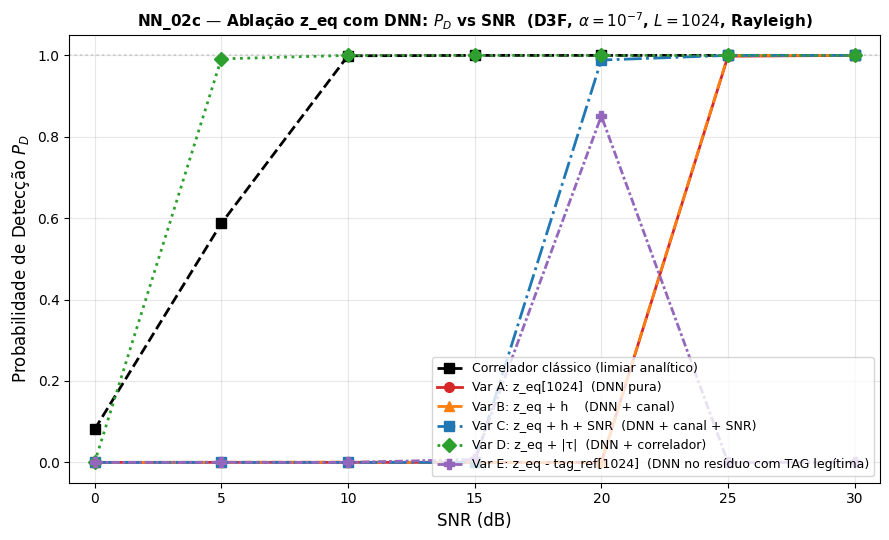

Figura salva → /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/visualizations/NN_02c_D3F_PD_vs_SNR_DNN.png

Variante  Input                             0dB      5dB     10dB     15dB     20dB     25dB     30dB
------------------------------------------------------------------------------------------
Clás   Correlador analítico              8.1     58.7     99.9    100.0    100.0    100.0    100.0
A      z_eq[1024]  (DNN pura)            0.0      0.0      0.0      0.0      0.0     99.8    100.0
B      z_eq + h    (DNN + canal)         0.0      0.0      0.1      0.0      0.0    100.0    100.0
C      z_eq + h + SNR  (DNN + canal + SNR)      0.0      0.0      0.0      0.0     98.8    100.0    100.0
D      z_eq + |τ|  (DNN + correlador)      0.0     99.1    100.0    100.0    100.0    100.0    100.0
E      z_eq - tag_ref[1024]  (DNN no resíduo com TAG legítima)      0.0      0.0      0.0      0.7     85.1      0.0      0.0
--------------------------------------

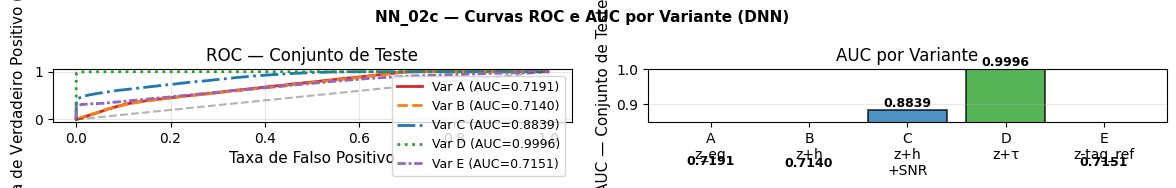

Figura salva → /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/visualizations/NN_02c_ROC_AUC_DNN.png


In [9]:
# ==============================================================================
# 6. VISUALIZAÇÕES: D3F PD vs SNR + ROC + AUC
# ==============================================================================

from sklearn.metrics import roc_auc_score, roc_curve

snr_arr    = np.array(SNR_BINS)
COLORS     = {'A': '#d62728', 'B': '#ff7f0e', 'C': '#1f77b4', 'D': '#2ca02c', 'E': '#9467bd'}
MARKERS    = {'A': 'o', 'B': '^', 'C': 's', 'D': 'D', 'E': 'P'}
LINESTYLES = {'A': '-', 'B': '--', 'C': '-.', 'D': ':', 'E': (0, (3, 1, 1, 1))}


# Gráfico 1: Probabilidade de detecção versus SNR sob framework D3F
fig1, ax1 = plt.subplots(figsize=(9, 5.5))

# Linha de referência: correlador clássico com limiar analítico
ax1.plot(snr_arr, [CLASSICAL_PD[s]/100 for s in SNR_BINS],
         color='black', ls='--', lw=2, marker='s', ms=7,
         label='Correlador clássico (limiar analítico)')

# Traços para cada variante
for var in ['A', 'B', 'C', 'D', 'E']:
    if var not in results_ablation: continue
    r  = results_ablation[var]
    pd = [r['pd_d3f'][s] for s in SNR_BINS]
    ax1.plot(snr_arr, pd,
             color=COLORS[var], ls=LINESTYLES[var], lw=2,
             marker=MARKERS[var], ms=7,
             label=f"Var {var}: {r['label']}")

ax1.set_xlabel('SNR (dB)', fontsize=12)
ax1.set_ylabel('Probabilidade de Detecção $P_D$', fontsize=12)
ax1.set_title(f'NN_02c — Ablação z_eq com DNN: $P_D$ vs SNR  (D3F, $\\alpha=10^{{-7}}$, $L=1024$, Rayleigh)',
              fontsize=11, fontweight='bold')
ax1.set_xlim(-1, 31); ax1.set_ylim(-0.05, 1.05)
ax1.set_xticks(SNR_BINS)
ax1.axhline(1.0, color='gray', ls=':', alpha=0.3)
ax1.legend(fontsize=9, loc='lower right')
ax1.grid(alpha=0.3)
plt.tight_layout()
vis1 = visualizations_dir / 'NN_02c_D3F_PD_vs_SNR_DNN.png'
plt.savefig(str(vis1), dpi=150)
plt.show()
print(f"Figura salva → {vis1}")

# Tabela resumida em formato texto
print(f"\n{'Variante':<5}  {'Input':<28}  " +
      "  ".join(f"{s:>5}dB" for s in SNR_BINS))
print("-" * 90)
cl_vals = "  ".join(f"{CLASSICAL_PD[s]:>7.1f}" for s in SNR_BINS)
print(f"{'Clás':<5}  {'Correlador analítico':<28}  {cl_vals}")
for var in ['A', 'B', 'C', 'D', 'E']:
    if var not in results_ablation: continue
    r = results_ablation[var]
    vals = "  ".join(f"{r['pd_d3f'][s]*100:>7.1f}" for s in SNR_BINS)
    print(f"{var:<5}  {r['label']:<28}  {vals}")
print("-" * 90)

# Gráfico 2: Curvas ROC e AUC por variante
fig3, axes3 = plt.subplots(1, 2, figsize=(12, 4.5))
fig3.suptitle('NN_02c — Curvas ROC e AUC por Variante (DNN)', fontsize=11, fontweight='bold')

ax_roc = axes3[0]
for var in ['A', 'B', 'C', 'D', 'E']:
    if var not in results_ablation: continue
    r   = results_ablation[var]
    auc = roc_auc_score(lbl_test_arr, r['sc_test'])
    fpr, tpr, _ = roc_curve(lbl_test_arr, r['sc_test'])
    ax_roc.plot(fpr, tpr, color=COLORS[var], ls=LINESTYLES[var], lw=2,
                label=f"Var {var} (AUC={auc:.4f})")
    results_ablation[var]['auc_test'] = round(auc, 6)

ax_roc.plot([0,1],[0,1],'k--', alpha=0.3)
ax_roc.set_xlabel('Taxa de Falso Positivo', fontsize=11); 
ax_roc.set_ylabel('Taxa de Verdadeiro Positivo ($P_D$)', fontsize=11)
ax_roc.set_title('ROC — Conjunto de Teste')
ax_roc.legend(fontsize=9)
ax_roc.grid(alpha=0.3)

# Gráfico de barras: AUC por variante
ax_auc = axes3[1]
aucs  = [results_ablation[v]['auc_test'] for v in ['A', 'B', 'C', 'D', 'E'] if v in results_ablation]
vlabs_map = {'A': 'A\nz_eq', 'B': 'B\nz+h', 'C': 'C\nz+h\n+SNR', 'D': 'D\nz+τ', 'E': 'E\nz-tag_ref'}
vlabs = [vlabs_map[v] for v in ['A', 'B', 'C', 'D', 'E'] if v in results_ablation]
bars  = ax_auc.bar(vlabs, aucs,
                   color=[COLORS[v] for v in ['A', 'B', 'C', 'D', 'E'] if v in results_ablation],
                   alpha=0.8, edgecolor='black', lw=1.2)
for bar, auc in zip(bars, aucs):
    ax_auc.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{auc:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_auc.set_ylabel('AUC — Conjunto de Teste', fontsize=11)
ax_auc.set_title('AUC por Variante')
ax_auc.set_ylim([0.85, 1.0])
ax_auc.grid(alpha=0.3, axis='y')

plt.tight_layout()
vis3 = visualizations_dir / 'NN_02c_ROC_AUC_DNN.png'
plt.savefig(str(vis3), dpi=150)
plt.show()
print(f"Figura salva → {vis3}")

In [10]:
# ============================================================================= =
# 7. FOCO NA VARIANTE E
# ============================================================================= =
if 'E' in results_ablation:
    ranking_auc = sorted(
        ((var, results_ablation[var].get('auc_test', results_ablation[var]['best_val_auc'])) for var in results_ablation),
        key=lambda item: item[1],
        reverse=True
    )
    ranking_pd0 = sorted(
        ((var, results_ablation[var]['pd_d3f'].get(0, 0.0)) for var in results_ablation),
        key=lambda item: item[1],
        reverse=True
    )
    e_auc = results_ablation['E'].get('auc_test', results_ablation['E']['best_val_auc'])
    e_pd0 = results_ablation['E']['pd_d3f'].get(0, 0.0) * 100
    print('Resumo Variante E (DNN):')
    print(f"  AUC      : {e_auc:.6f}")
    print(f"  PD @ 0dB : {e_pd0:.1f}%")
    print(f"  Ranking por AUC : {ranking_auc}")
    print(f"  Ranking por PD@0dB : {ranking_pd0}")
else:
    print('Treine ou recupere a Variante E para gerar este resumo.')

Resumo Variante E (DNN):
  AUC      : 0.715112
  PD @ 0dB : 0.0%
  Ranking por AUC : [('D', 0.999638), ('C', 0.883914), ('A', 0.71915), ('E', 0.715112), ('B', 0.714038)]
  Ranking por PD@0dB : [('A', 0.0), ('B', 0.0), ('C', 0.0), ('D', 0.0), ('E', 0.0)]
